In [43]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as pit
import seaborn as sns

In [44]:
df=pd.read_csv("C:\\Users\\Gouthamiyadav\\OneDrive\\Desktop\\vscode\\HR_Employee Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


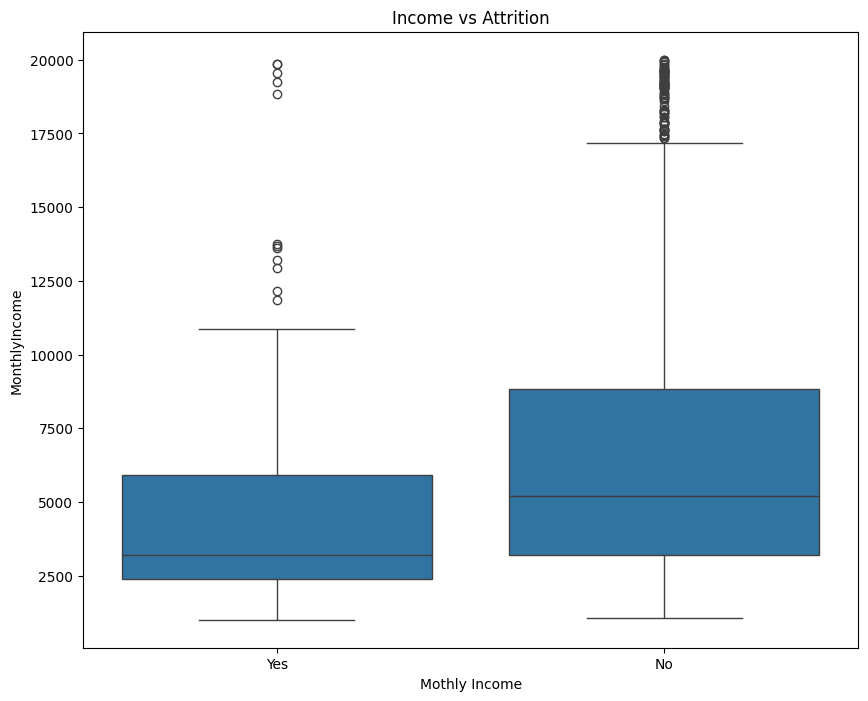

In [45]:
pit.figure(figsize=(10,8))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
pit.title("Income vs Attrition")
pit.xlabel("Mothly Income")
pit.show()

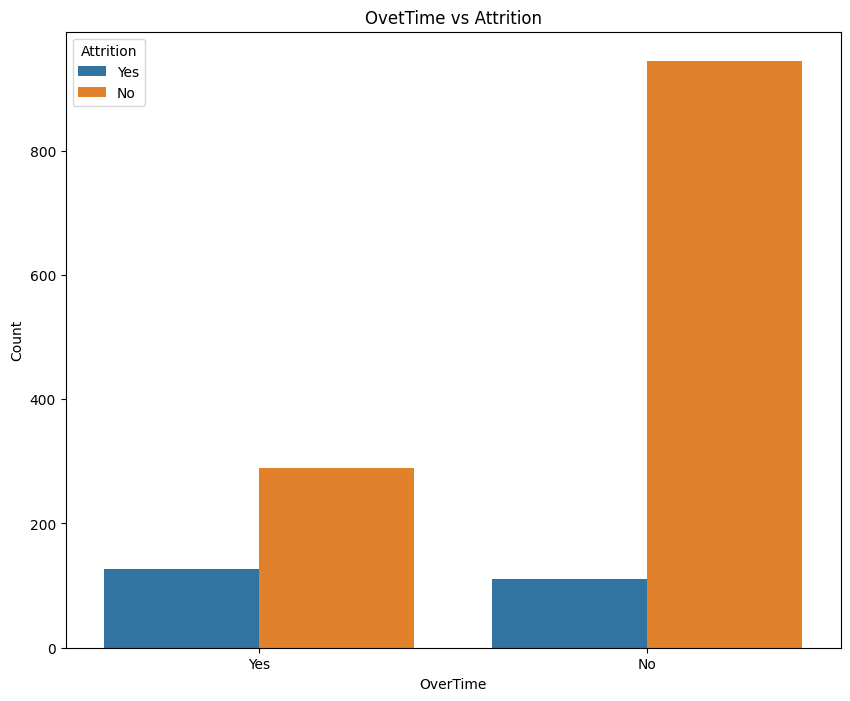

In [46]:
pit.figure(figsize=(10,8))
sns.countplot(x="OverTime",hue="Attrition",data=df)
pit.title("OvetTime vs Attrition")
pit.xlabel("OverTime")
pit.ylabel("Count")
pit.legend(title="Attrition")
pit.show()

In [47]:
df.drop(["EmployeeNumber","EmployeeCount","Over18","StandardHours"],axis=1,inplace=True)
#df.info()
encoder={}
for col in df.select_dtypes(include=["object"]).columns:
    lb=LabelEncoder()
    df[col]=lb.fit_transform(df[col])
    X=df.drop("Attrition",axis=1)
    y=df["Attrition"]
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

In [48]:
rf=RandomForestClassifier(random_state=42)
param_grid={
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}
grid_search=GridSearchCV(rf,param_grid,cv=5,scoring='f1')
grid_search.fit(X_train,y_train)
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [49]:
model=RandomForestClassifier(**grid_search.best_params_,random_state=42)
model.fit(X,y)
joblib.dump(model,"employee_attrition_model.pkl")
joblib.dump(lb,"label_encoder.pkl")
joblib.dump(X.columns,"feature_columns.pkl")

['feature_columns.pkl']

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.81      0.16      0.27        81

    accuracy                           0.88       588
   macro avg       0.85      0.58      0.60       588
weighted avg       0.87      0.88      0.84       588

[[504   3]
 [ 68  13]]


Text(0, 0.5, 'Feature')

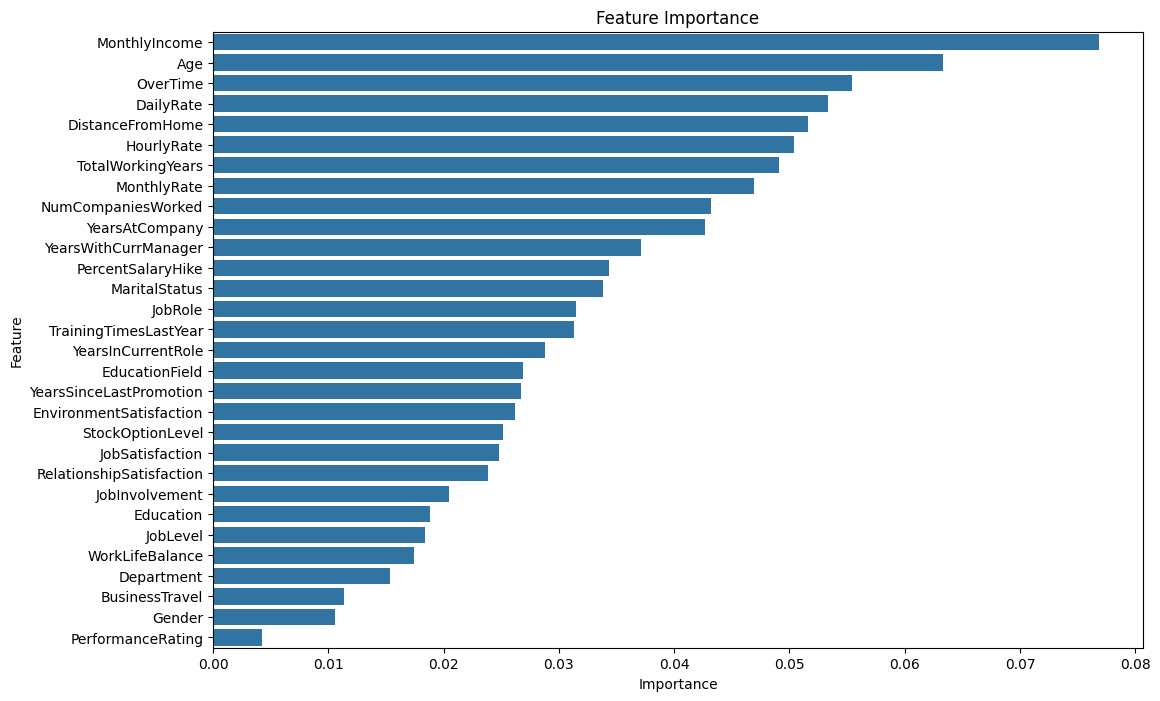

In [50]:
best_model=grid_search.best_estimator_
predictions=best_model.predict(X_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))
importances=best_model.feature_importances_
feature_importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importances
}).sort_values(by="Importance",ascending=False)
pit.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Feature",data=feature_importance_df)
pit.title("Feature Importance")
pit.xlabel("Importance")
pit.ylabel("Feature")